<a href="https://colab.research.google.com/github/adapasriram/Stock-Trading-System/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/US_honey_dataset.csv')

In [4]:
df

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...,...
1110,1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [ ]:
df = df.drop('Unnamed: 0',axis = 1)

In [ ]:
df

,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
0,Alabama,16000,58,928000,28000,62.00,575000,1995
1,Arizona,52000,79,4108000,986000,68.00,2793000,1995
2,Arkansas,50000,60,3000000,900000,64.00,1920000,1995
3,California,420000,93,39060000,4687000,60.00,23436000,1995
4,Colorado,45000,60,2700000,1404000,68.00,1836000,1995
...,...,...,...,...,...,...,...,...
1110,Virginia,6000,40,79000,79000,8.23,1975000,2021
1111,Washington,96000,32,1206000,1206000,2.52,7741000,2021
1112,WestVirginia,6000,43,136000,136000,4.80,1238000,2021
1113,Wisconsin,42000,47,750000,750000,2.81,5547000,2021


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   state                1115 non-null   object 
 1   colonies_number      1115 non-null   int64  
 2   yield_per_colony     1115 non-null   int64  
 3   production           1115 non-null   int64  
 4   stocks               1115 non-null   int64  
 5   average_price        1115 non-null   float64
 6   value_of_production  1115 non-null   int64  
 7   year                 1115 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 69.8+ KB


In [5]:
df.isna().sum()

,0
Unnamed: 0,0
state,0
colonies_number,0
yield_per_colony,0
production,0
stocks,0
average_price,0
value_of_production,0
year,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
#check how many states are there
df['state'].nunique()


44

In [8]:
df['year'].nunique()

27

In [ ]:

1.Which states are rarely contributing to honey production for the last 27 years

In [9]:
data = df['state'].value_counts(ascending = True).head(5)

In [10]:
data

,count
state,
Oklahoma,9
Maryland,9
SouthCarolina,12
Nevada,15
NewMexico,18


In [11]:
data

,count
state,
Oklahoma,9
Maryland,9
SouthCarolina,12
Nevada,15
NewMexico,18


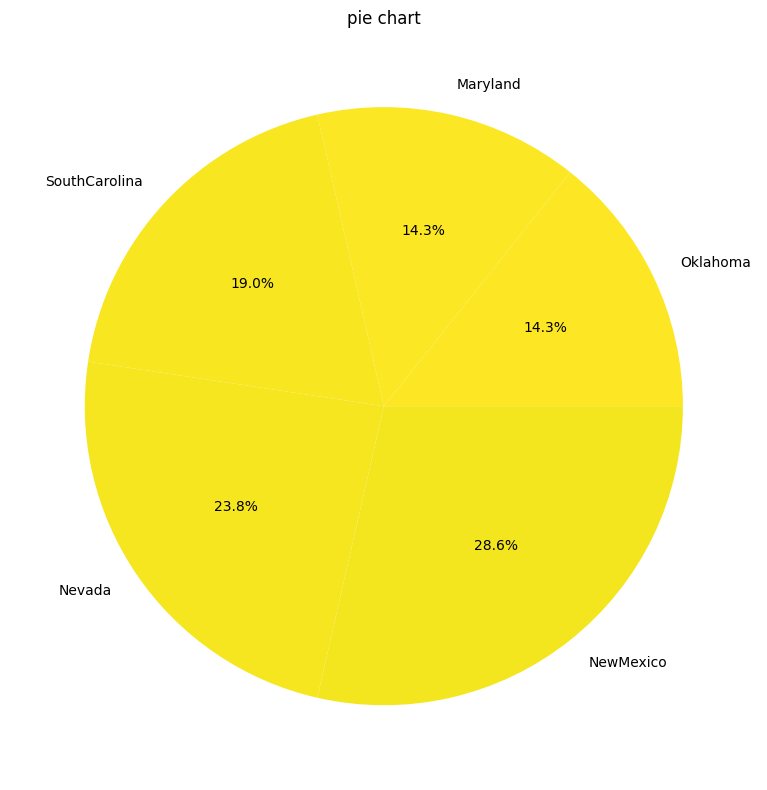

In [12]:
plt.figure(figsize = (10,8))
colors = plt.cm.viridis_r.colors

plt.pie(data.values,labels = data.index,
        autopct = '%.1f%%',
        colors = colors)

plt.title('pie chart')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Count of Honey Production by State')

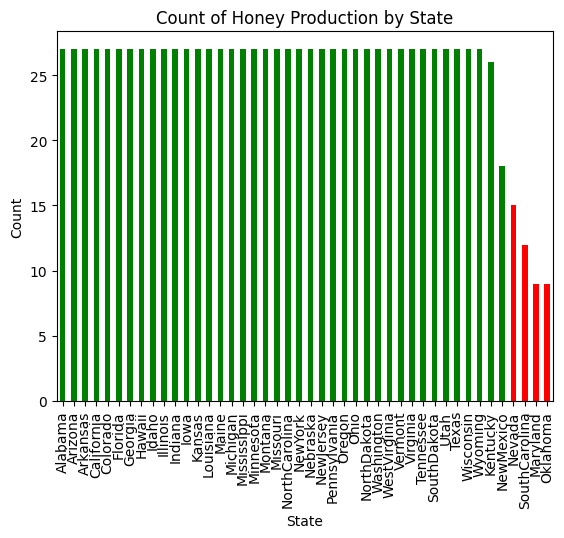

In [13]:
data = df['state'].value_counts()

colors = ['red' if value < 18 else 'green' for value in data]
data.plot(kind = 'bar',color = colors)
plt.xlabel('State')
plt.ylabel('Count')
plt.title('Count of Honey Production by State')

In [14]:
df_sorted = df.sort_values(by = 'production',ascending = False)

/tmp/ipykernel_6371/281662758.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


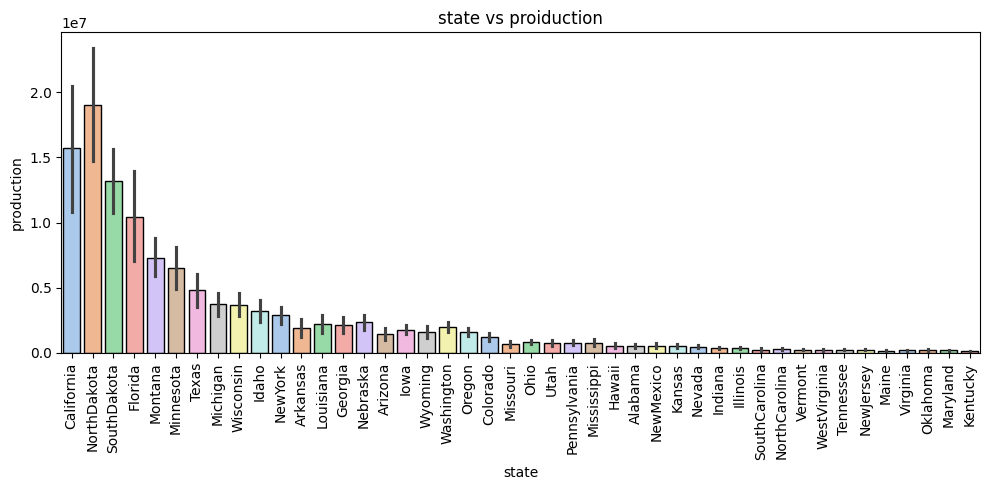

In [15]:
plt.figure(figsize = (10,5))
sns.barplot(
    x = df_sorted['state'],
    y = df_sorted['production'],
    palette = 'pastel',
    edgecolor = 'black'
)
plt.xticks(rotation = 90)

plt.xlabel('state')
plt.ylabel('production')
plt.title('state vs proiduction')
plt.tight_layout()
plt.show()

In [16]:
df_sorted

,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
3,3,California,420000,93,39060000,4687000,60.00,23436000,1995
134,134,California,450000,83,37350000,12326000,62.00,23157000,1998
581,581,NorthDakota,390000,90,35100000,8424000,135.00,47385000,2008
622,622,NorthDakota,450000,77,34650000,7623000,137.00,47471000,2009
458,458,NorthDakota,370000,91,33670000,8418000,81.00,27273000,2005
...,...,...,...,...,...,...,...,...,...
769,769,Kentucky,3000,41,17000,17000,325.00,400000,2013
984,984,SouthCarolina,16000,48,15000,15000,3.17,2435000,2018
955,955,Alabama,6000,45,14000,14000,3.72,1004000,2018
835,835,Alabama,7000,47,13000,13000,383.00,1260000,2015


3.WHAT IS THE CHANGE IN MEAN AVERAGE PRICE OF HONEY FROM 1995 TO 2021

In [17]:
df2 = df.groupby('year').mean(['average_price'])

In [18]:
df2

,Unnamed: 0,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production
year,,,,,,,
1995,21.5,59977.272727,66.909091,4.778909e+06,9.575000e+05,74.840909,3.121000e+06
1996,65.5,58181.818182,70.068182,4.499886e+06,1.066455e+06,99.568182,4.085773e+06
1997,109.0,59651.162791,68.953488,4.445953e+06,1.601256e+06,91.325581,3.386000e+06
1998,152.0,60883.720930,69.953488,5.100488e+06,1.871488e+06,83.720930,3.395302e+06
1999,195.0,62186.046512,65.465116,4.757791e+06,1.839698e+06,80.325581,2.888070e+06
2000,238.0,60860.465116,67.534884,5.123721e+06,1.997395e+06,79.023256,3.047023e+06
2001,281.0,58139.534884,65.209302,4.311698e+06,1.501791e+06,88.465116,2.936302e+06
2002,324.5,57181.818182,67.272727,3.880273e+06,8.831591e+05,133.204545,5.016977e+06
2003,368.5,58681.818182,62.522727,4.107750e+06,9.220227e+05,151.068182,5.791659e+06


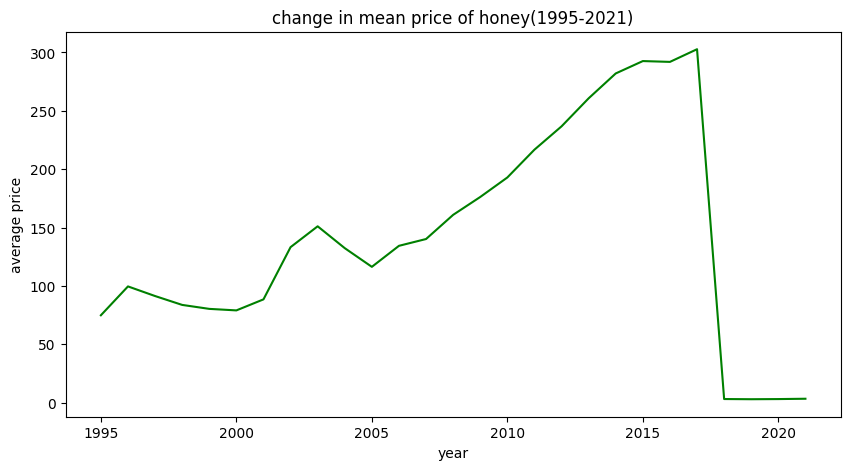

In [19]:
plt.figure(figsize = (10,5))
sns.lineplot(
    x = df2.index,
    y = df2['average_price'],
    color = 'green'
)
plt.xlabel('year')
plt.ylabel('average price')
plt.title('change in mean price of honey(1995-2021)')
plt.show()

3  Which was the year when production of honey in wholeUS was the highest

In [20]:
data3 = df.groupby('year').sum()['production'].reset_index()

In [ ]:
data3

,year,production
0,1995,210272000
1,1996,197995000
2,1997,191176000
3,1998,219321000
4,1999,204585000
5,2000,220320000
6,2001,185403000
7,2002,170732000
8,2003,180741000
9,2004,182379000


In [21]:
data3_sorted = data3.sort_values(by='production',ascending = False)

/tmp/ipykernel_6371/2267543019.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = data3['year'],y = data3['production'],


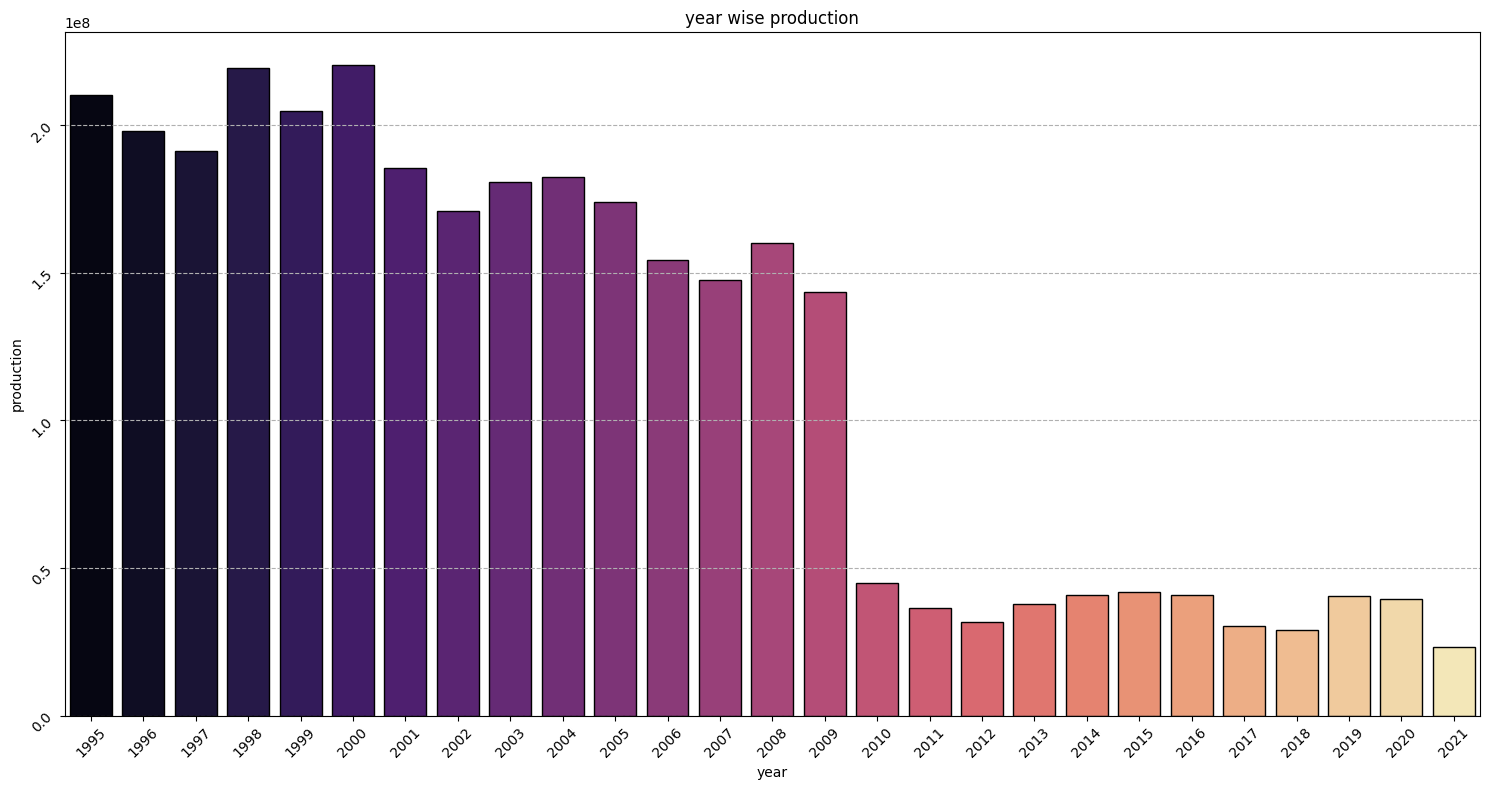

In [23]:
plt.figure(figsize = (15,8))
sns.barplot(x = data3['year'],y = data3['production'],
        palette = 'magma',
        edgecolor = 'black'
        )

plt.title('year wise production')
plt.xlabel('year')
plt.ylabel('production')
plt.xticks(rotation = 45)
plt.yticks(rotation = 45)
plt.grid(axis = 'y',linestyle = '--')
plt.tight_layout()
plt.show()

In [26]:
data = df[df['year'] == 2000]

In [27]:
data


,Unnamed: 0,state,colonies_number,yield_per_colony,production,stocks,average_price,value_of_production,year
217,217,Alabama,16000,78,1248000,187000,59.0,736000,2000
218,218,Arizona,40000,59,2360000,1322000,73.0,1723000,2000
219,219,Arkansas,55000,93,5115000,3529000,57.0,2916000,2000
220,220,California,440000,70,30800000,11396000,58.0,17864000,2000
221,221,Colorado,29000,60,1740000,957000,62.0,1079000,2000
222,222,Florida,232000,105,24360000,2923000,54.0,13154000,2000
223,223,Georgia,55000,57,3135000,376000,63.0,1975000,2000
224,224,Hawaii,7000,112,784000,125000,81.0,635000,2000
225,225,Idaho,100000,47,4700000,2679000,52.0,2444000,2000
226,226,Illinois,8000,61,488000,146000,117.0,571000,2000


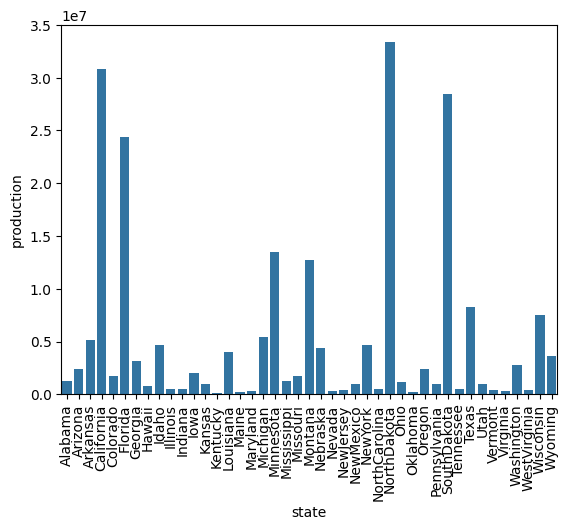

In [29]:
sns.barplot(x=data['state'],y = data['production'])
plt.xticks(rotation = 90)
plt.show()

/tmp/ipykernel_6371/1372738049.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = year_2000_sorted['state'],y= year_2000_sorted['colonies_number'],palette = 'magma',edgecolor='black')


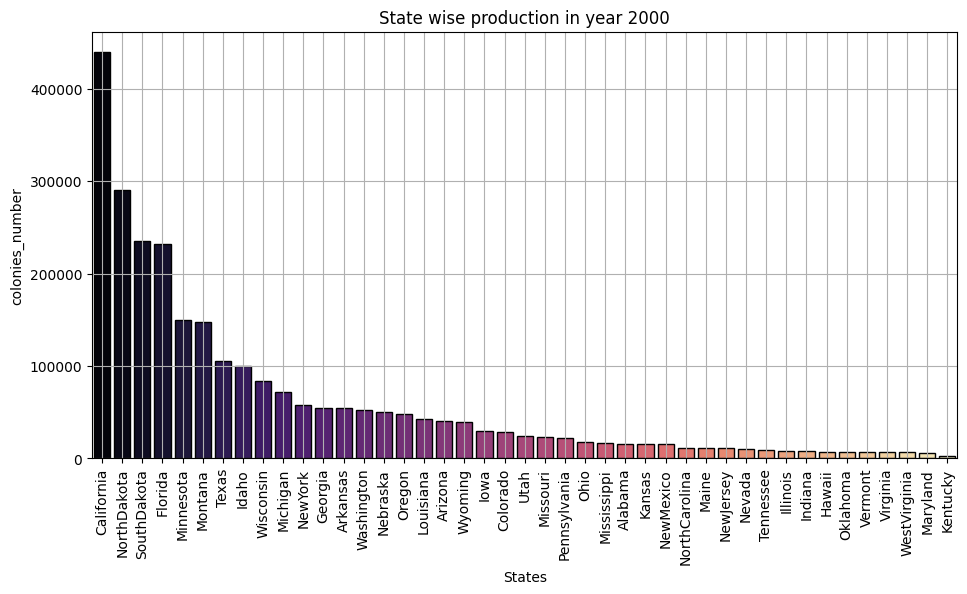

In [32]:
year_2000= df[df['year']== 2000]

year_2000_sorted = year_2000.sort_values(by='colonies_number',ascending = False)

plt.figure(figsize = (10,5))
ax = sns.barplot(x = year_2000_sorted['state'],y= year_2000_sorted['colonies_number'],palette = 'magma',edgecolor='black')

plt.tight_layout()
plt.title('State wise production in year 2000')
plt.xlabel('States')
plt.ylabel('colonies_number')
plt.xticks(rotation=90)
plt.grid()
plt.show()